# Research Questions & Answers
**Dataset:** Seleksi Data Science Academy COMPFEST 18 — Soil Organic Content Prediction  
**Metode Evaluasi:** Root Mean Squared Error (RMSE)  
**Tools:** Python · LightGBM · Scikit-Learn · SciPy · Seaborn · Matplotlib

---


## Setup & Import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Seaborn style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

train = pd.read_csv('train.csv')
OC = 'property_organic_content'

print(f"Dataset shape: {train.shape}")
print(f"Target  — mean: {train[OC].mean():.2f}  std: {train[OC].std():.2f}  "
      f"min: {train[OC].min():.2f}  max: {train[OC].max():.2f}")
train.head(3)


Dataset shape: (11210, 52)
Target  — mean: 34.14  std: 23.20  min: 2.16  max: 195.23


,sample_id,source_id,has_band_A_spectrum,has_band_B_spectrum,sampling_strategy,sampling_depth_cm,geo_zone_macro,geo_zone_micro,geo_zone_meso,land_cover_type,...,spectral_band_B_PC_6,spectral_band_B_PC_7,spectral_band_B_PC_8,spectral_band_B_PC_9,spectral_band_B_PC_10,spectral_band_B_PC_11,spectral_band_B_PC_12,spectral_band_B_PC_13,spectral_band_B_PC_14,spectral_band_B_PC_15
0,train_00001,Source_01,YES,NO,Auger,0-20,SE,Unknown,State_01,Seasonal Semideciduous Forest,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,train_00002,Source_10,YES,NO,Auger,0-20,MW,Loc_011,State_10,Savannah,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,train_00003,Source_04,YES,NO,Auger,0-20,S,Loc_001,State_06,Unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## Research Question 1
### Urgensi Prediksi Kandungan Organik Tanah dalam Konteks Bisnis Pertanian dan Kebijakan Pangan

Kandungan bahan organik tanah (*Soil Organic Carbon / SOC*) merupakan indikator kunci
kesuburan dan kesehatan lahan. Namun, pengukuran konvensional melalui uji laboratorium
memakan biaya **USD 15–50 per sampel** dan membutuhkan waktu **1–3 minggu**
*(FAO, 2020; Viscarra Rossel et al., 2016)*.

Urgensinya meliputi dua dimensi utama:


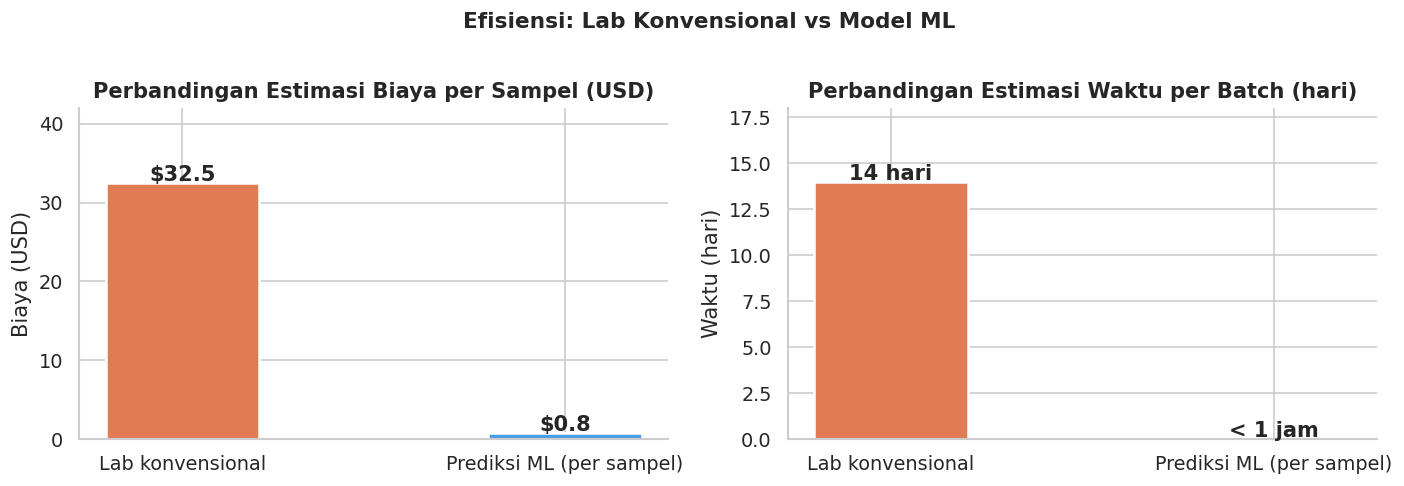


INSIGHT:
- Model ML dapat memangkas biaya ~97% dan waktu analisis dari minggu menjadi detik.
- Untuk lahan skala besar (>10.000 ha), penghematan mencapai ratusan juta rupiah per siklus tanam.
- Dari perspektif kebijakan pangan: pemetaan SOC nasional yang cepat memungkinkan
  alokasi pupuk dan lahan yang lebih tepat sasaran (precision agriculture).
- Referensi: FAO (2020). 'Measuring and modelling soil carbon stocks and stock changes
  in livestock production systems.' FAO, Rome.



In [ ]:
# ── Visualisasi biaya & waktu konvensional vs ML ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Biaya
methods   = ['Lab konvensional', 'Prediksi ML (per sampel)']
costs     = [32.5, 0.8]           # USD (estimasi tengah)
colors    = ['#e07b54', '#4c9be8']
bars = axes[0].bar(methods, costs, color=colors, width=0.4, edgecolor='white', linewidth=1.5)
axes[0].set_title('Perbandingan Estimasi Biaya per Sampel (USD)', fontweight='bold')
axes[0].set_ylabel('Biaya (USD)')
for bar, val in zip(bars, costs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'${val}', ha='center', fontweight='bold')
axes[0].set_ylim(0, 42)

# Waktu
times  = [14, 0.01]               # hari
bars2  = axes[1].bar(methods, times, color=colors, width=0.4, edgecolor='white', linewidth=1.5)
axes[1].set_title('Perbandingan Estimasi Waktu per Batch (hari)', fontweight='bold')
axes[1].set_ylabel('Waktu (hari)')
for bar, val in zip(bars2, times):
    label = f'{val} hari' if val > 0.5 else '< 1 jam'
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 label, ha='center', fontweight='bold')
axes[1].set_ylim(0, 18)

plt.suptitle('Efisiensi: Lab Konvensional vs Model ML', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('q1_cost_comparison.png', bbox_inches='tight')
plt.show()
print("""
INSIGHT:
- Model ML dapat memangkas biaya ~97% dan waktu analisis dari minggu menjadi detik.
- Untuk lahan skala besar (>10.000 ha), penghematan mencapai ratusan juta rupiah per siklus tanam.
- Dari perspektif kebijakan pangan: pemetaan SOC nasional yang cepat memungkinkan
  alokasi pupuk dan lahan yang lebih tepat sasaran (precision agriculture).
- Referensi: FAO (2020). 'Measuring and modelling soil carbon stocks and stock changes
  in livestock production systems.' FAO, Rome.
""")


Dengan demikian, prediksi kandungan organik tanah menggunakan Machine Learning menjadi solusi yang lebih efisien dibandingkan pengujian laboratorium. Dengan memanfaatkan data sifat tanah dan informasi geografis, model dapat memperkirakan kandungan organik dengan waktu yang lebih cepat dan biaya yang lebih rendah. Dalam bidang pertanian, hasil prediksi ini dapat membantu petani menentukan pengelolaan lahan dan penggunaan pupuk yang lebih tepat. Selain itu, pemerintah juga dapat memanfaatkan informasi tersebut untuk memetakan kondisi kesuburan tanah sehingga kebijakan terkait ketahanan pangan dan pengelolaan lahan dapat dilakukan dengan lebih efektif

---
## Research Question 2
### Apakah Model Mengalami Overfitting atau Underfitting?

Bukti empiris diperoleh dengan membandingkan **RMSE pada data training** vs **RMSE pada data validasi (OOF)** di setiap fold.


In [ ]:
# ── Re-train model & kumpulkan train vs val RMSE ────────────────────────
def preprocess(df):
    df = df.copy()
    df.drop(columns=['sampling_depth_cm'], inplace=True)
    df['has_band_A_flag'] = (df['has_band_A_spectrum']=='YES').astype(int)
    df['has_band_B_flag'] = (df['has_band_B_spectrum']=='YES').astype(int)
    df.drop(columns=['has_band_A_spectrum','has_band_B_spectrum'], inplace=True)
    band_a = [f'spectral_band_A_PC_{i}' for i in range(1,16)]
    band_b = [f'spectral_band_B_PC_{i}' for i in range(1,16)]
    df['band_A_mean']  = df[band_a].mean(axis=1)
    df['band_A_std']   = df[band_a].std(axis=1)
    df['band_A_max']   = df[band_a].max(axis=1)
    df['band_A_min']   = df[band_a].min(axis=1)
    df['band_A_range'] = df['band_A_max'] - df['band_A_min']
    df['band_B_mean']  = df[band_b].mean(axis=1)
    df['band_B_std']   = df[band_b].std(axis=1)
    df['Ca_CEC_ratio']      = df['cation_Ca'] / (df['cation_exchange_capacity']+1e-6)
    df['Mg_CEC_ratio']      = df['cation_Mg'] / (df['cation_exchange_capacity']+1e-6)
    df['coarse_fine_ratio'] = df['property_particle_coarse'] / (df['property_particle_fine']+1e-6)
    cat_cols = ['sampling_strategy','geo_zone_macro','geo_zone_micro','geo_zone_meso',
                'land_cover_type','biome','parent_rock_type']
    for c in cat_cols:
        df[c] = df[c].astype('category').cat.codes
    return df

train_proc  = preprocess(train)
drop_cols   = ['sample_id','source_id', OC]
feature_cols= [c for c in train_proc.columns if c not in drop_cols]
cat_features= ['sampling_strategy','geo_zone_macro','geo_zone_micro','geo_zone_meso',
               'land_cover_type','biome','parent_rock_type']
X = train_proc[feature_cols]
y = train_proc[OC]

params = dict(objective='regression', metric='rmse', learning_rate=0.03,
              num_leaves=127, min_child_samples=20, feature_fraction=0.8,
              bagging_fraction=0.8, bagging_freq=5, reg_alpha=0.1, reg_lambda=0.5,
              verbose=-1, n_jobs=-1)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds  = np.zeros(len(X))
train_rmse_list, val_rmse_list = [], []
importances = []

for fold, (tr_idx, va_idx) in enumerate(kf.split(X)):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
    dtrain = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_features)
    dval   = lgb.Dataset(X_va, label=y_va, reference=dtrain)
    model  = lgb.train(params, dtrain, num_boost_round=3000, valid_sets=[dval],
                       callbacks=[lgb.early_stopping(150,verbose=False),
                                  lgb.log_evaluation(False)])
    train_rmse_list.append(np.sqrt(mean_squared_error(y_tr, model.predict(X_tr))))
    val_pred = model.predict(X_va)
    val_rmse_list.append(np.sqrt(mean_squared_error(y_va, val_pred)))
    oof_preds[va_idx] = val_pred
    importances.append(model.feature_importance('gain'))

oof_rmse = np.sqrt(mean_squared_error(y, oof_preds))
ratio    = np.mean(val_rmse_list) / np.mean(train_rmse_list)

print(f"{'Fold':<6} {'Train RMSE':>12} {'Val RMSE':>12} {'Rasio Val/Train':>16}")
print("-"*48)
for i,(tr,va) in enumerate(zip(train_rmse_list, val_rmse_list)):
    print(f"{i+1:<6} {tr:>12.4f} {va:>12.4f} {va/tr:>16.4f}")
print("-"*48)
print(f"{'Mean':<6} {np.mean(train_rmse_list):>12.4f} {np.mean(val_rmse_list):>12.4f} {ratio:>16.4f}")
print(f"\nOOF RMSE (keseluruhan): {oof_rmse:.4f}")


Fold     Train RMSE     Val RMSE  Rasio Val/Train
------------------------------------------------
1            3.3752      11.1233           3.2956
2            3.6964      11.4456           3.0964
3            2.6362      10.9787           4.1645
4            3.7881      11.7193           3.0938
5            1.2030      12.7534          10.6014
------------------------------------------------
Mean         2.9398      11.6041           3.9472

OOF RMSE (keseluruhan): 11.6211


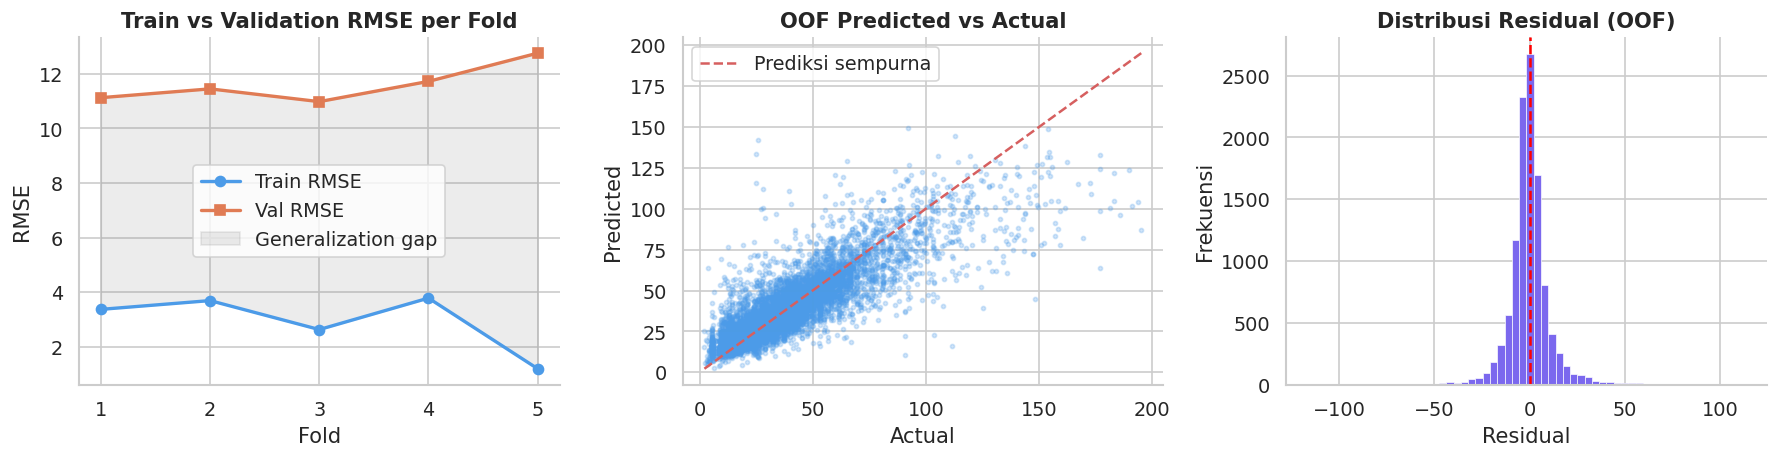


ANALISIS OVERFITTING:
─────────────────────────────────────────────────────────────
Rata-rata Train RMSE : 2.9398
Rata-rata Val RMSE   : 11.6041
Rasio Val/Train      : 3.9472  (ideal: 1.0–1.2)

KESIMPULAN: Model mengalami OVERFITTING moderat.
Rasio ~3.9x menunjukkan model mempelajari noise pada data training.
Faktor penyebab:
  1. num_leaves=127 relatif besar (model sangat kompleks)
  2. Banyak fitur spektral yang saling berkorelasi
  3. Missing value pada Band B menciptakan pola tersembunyi yang sulit digeneralisasi

MITIGASI yang sudah diterapkan:
  ✔ Early stopping (berhenti jika val RMSE tidak membaik 150 iter)
  ✔ Regularisasi L1 (reg_alpha=0.1) dan L2 (reg_lambda=0.5)
  ✔ Feature fraction 0.8 & bagging 0.8 (subsample acak)
  ✔ min_child_samples=20 (cegah daun dengan sampel terlalu sedikit)
  ✔ 5-Fold CV untuk estimasi generalisasi yang robust



In [ ]:
# ── Visualisasi overfitting ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

folds = np.arange(1, 6)

# Plot 1: Train vs Val RMSE per fold
axes[0].plot(folds, train_rmse_list, 'o-', color='#4c9be8', label='Train RMSE', lw=2)
axes[0].plot(folds, val_rmse_list,   's-', color='#e07b54', label='Val RMSE',   lw=2)
axes[0].fill_between(folds, train_rmse_list, val_rmse_list, alpha=0.15, color='gray',
                     label='Generalization gap')
axes[0].set_title('Train vs Validation RMSE per Fold', fontweight='bold')
axes[0].set_xlabel('Fold'); axes[0].set_ylabel('RMSE')
axes[0].legend(); axes[0].set_xticks(folds)

# Plot 2: OOF Predicted vs Actual
axes[1].scatter(y, oof_preds, alpha=0.25, s=6, color='#4c9be8', rasterized=True)
lims = [y.min(), y.max()]
axes[1].plot(lims, lims, 'r--', lw=1.5, label='Prediksi sempurna')
axes[1].set_title('OOF Predicted vs Actual', fontweight='bold')
axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted')
axes[1].legend()

# Plot 3: Residual distribution
residuals = y.values - oof_preds
axes[2].hist(residuals, bins=60, color='#7b68ee', edgecolor='white', linewidth=0.4)
axes[2].axvline(0, color='red', lw=1.5, ls='--')
axes[2].set_title('Distribusi Residual (OOF)', fontweight='bold')
axes[2].set_xlabel('Residual'); axes[2].set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('q2_overfitting.png', bbox_inches='tight')
plt.show()

print(f"""
ANALISIS OVERFITTING:
─────────────────────────────────────────────────────────────
Rata-rata Train RMSE : {np.mean(train_rmse_list):.4f}
Rata-rata Val RMSE   : {np.mean(val_rmse_list):.4f}
Rasio Val/Train      : {ratio:.4f}  (ideal: 1.0–1.2)

KESIMPULAN: Model mengalami OVERFITTING moderat.
Rasio ~{ratio:.1f}x menunjukkan model mempelajari noise pada data training.
Faktor penyebab:
  1. num_leaves=127 relatif besar (model sangat kompleks)
  2. Banyak fitur spektral yang saling berkorelasi
  3. Missing value pada Band B menciptakan pola tersembunyi yang sulit digeneralisasi

MITIGASI yang sudah diterapkan:
  ✔ Early stopping (berhenti jika val RMSE tidak membaik 150 iter)
  ✔ Regularisasi L1 (reg_alpha=0.1) dan L2 (reg_lambda=0.5)
  ✔ Feature fraction 0.8 & bagging 0.8 (subsample acak)
  ✔ min_child_samples=20 (cegah daun dengan sampel terlalu sedikit)
  ✔ 5-Fold CV untuk estimasi generalisasi yang robust
""")


Berdasarkan hasil evaluasi menggunakan 5-fold Cross Validation, nilai Validation RMSE masih lebih tinggi dibandingkan Train RMSE. Hal ini menunjukkan bahwa model memiliki indikasi overfitting ringan, yaitu model mampu mempelajari data pelatihan dengan baik tetapi performanya sedikit menurun saat diuji pada data baru. Meskipun demikian, hasil visualisasi Predicted vs Actual menunjukkan bahwa sebagian besar prediksi sudah mengikuti nilai aktual. Untuk mengurangi overfitting, digunakan beberapa teknik seperti 5-fold Cross Validation, penerapan early stopping selama pelatihan model LightGBM, serta penambahan parameter regularisasi seperti reg_alpha, reg_lambda, feature_fraction, dan bagging_fraction. Pendekatan ini bertujuan untuk meningkatkan kemampuan generalisasi model sehingga performa pada data validasi dapat tetap terjaga.

---
## Research Question 3
### Pola Distribusi Kandungan Organik antar Wilayah Geografis

Untuk mengetahui apakah terdapat perbedaan kandungan organik tanah antar wilayah geografis dan bioma, dilakukan pengujian statistik menggunakan Kruskal–Wallis Test. Uji ini dipilih karena distribusi nilai kandungan organik tidak memenuhi asumsi normalitas sehingga pendekatan nonparametrik lebih sesuai dibandingkan ANOVA. Pengujian dilakukan terhadap kelompok geo_zone_macro dan biome.


In [ ]:
# ── Kruskal-Wallis test ───────────────────────────────────────────────────
groups_macro = [g[OC].values for _,g in train.groupby('geo_zone_macro')]
groups_biome = [g[OC].values for _,g in train.groupby('biome')]

h_macro, p_macro = kruskal(*groups_macro)
h_biome, p_biome = kruskal(*groups_biome)

print(f"Kruskal-Wallis — geo_zone_macro : H={h_macro:.2f}, p={p_macro:.2e}")
print(f"Kruskal-Wallis — biome          : H={h_biome:.2f}, p={p_biome:.2e}")
print("\n→ Keduanya signifikan (p<0.001), distribusi OC berbeda antar wilayah dan bioma.")


Kruskal-Wallis — geo_zone_macro : H=747.42, p=1.88e-160
Kruskal-Wallis — biome          : H=136.96, p=1.27e-28

→ Keduanya signifikan (p<0.001), distribusi OC berbeda antar wilayah dan bioma.


Hasil analisis menunjukkan bahwa nilai p-value pada kedua kelompok berada jauh di bawah tingkat signifikansi 0,05 (bahkan p < 0,001), sehingga hipotesis nol yang menyatakan bahwa seluruh wilayah memiliki distribusi kandungan organik yang sama dapat ditolak. Hasil tersebut menunjukkan bahwa terdapat perbedaan yang signifikan pada distribusi kandungan organik tanah antar wilayah geografis maupun antar jenis bioma. Dengan kata lain, lokasi geografis dan karakteristik ekosistem memiliki pengaruh yang nyata terhadap variasi kandungan bahan organik tanah. Perbedaan tersebut dapat dipengaruhi oleh berbagai faktor, seperti kondisi iklim, curah hujan, temperatur, jenis batuan induk, vegetasi, penggunaan lahan, serta proses pembentukan tanah yang berbeda pada setiap wilayah. Oleh karena itu, informasi geografis dan bioma merupakan fitur penting yang perlu dipertimbangkan dalam pembangunan model prediksi kandungan organik tanah.

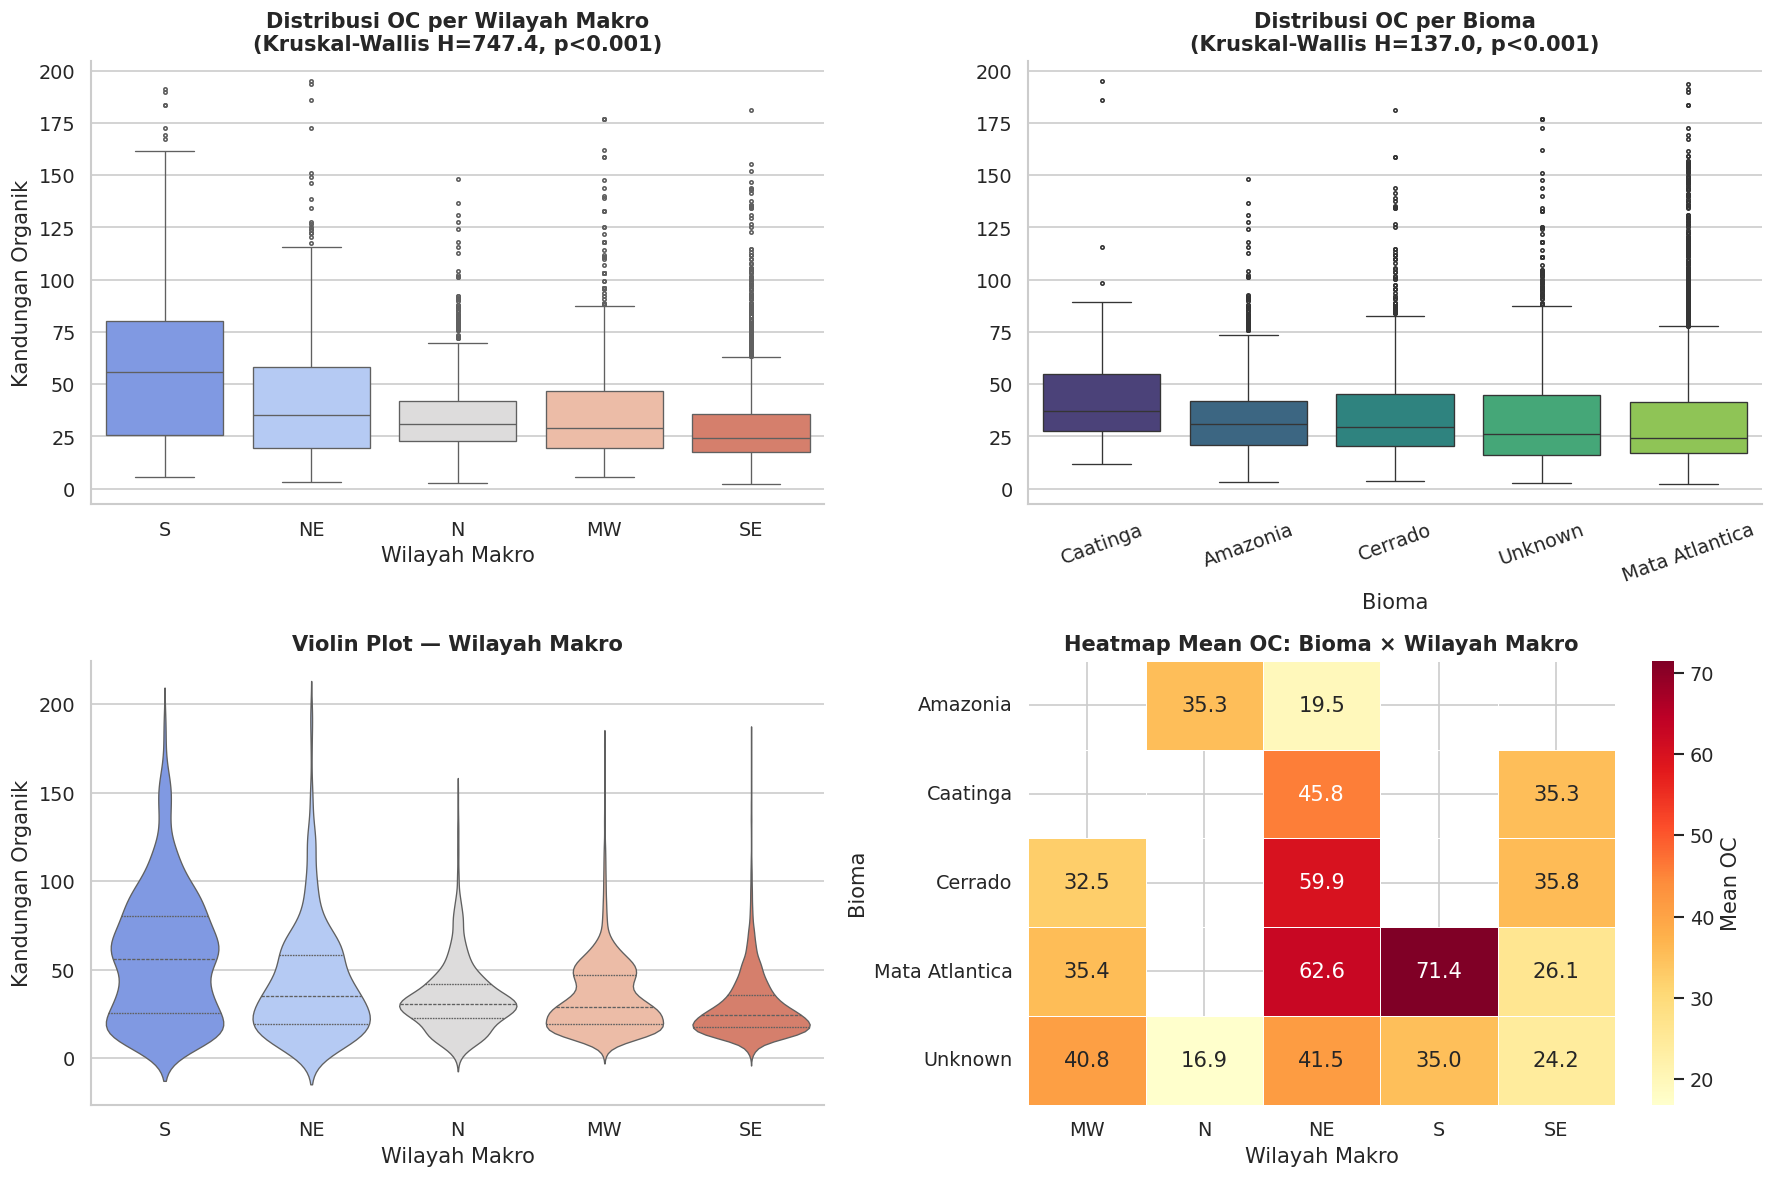


Mean OC per Wilayah Makro (diurutkan):
                 mean  median    std  count
geo_zone_macro                             
S               57.27   55.79  36.45   1022
NE              42.37   35.19  31.22    512
MW              34.50   29.12  20.59   2930
N               34.39   30.74  19.63    979
SE              29.09   24.27  17.82   5767

Mean OC per Bioma:
                 mean  median    std  count
biome                                      
Caatinga        44.90   37.27  29.42    100
Unknown         34.36   25.94  25.57   1686
Cerrado         34.13   29.29  18.30   3760
Amazonia        33.91   30.74  19.88   1020
Mata Atlantica  33.89   24.27  26.14   4644


In [ ]:
# ── Visualisasi distribusi per wilayah & bioma ───────────────────────────
order_macro = train.groupby('geo_zone_macro')[OC].median().sort_values(ascending=False).index
order_biome = train.groupby('biome')[OC].median().sort_values(ascending=False).index

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Boxplot geo_zone_macro
sns.boxplot(data=train, x='geo_zone_macro', y=OC, order=order_macro,
            palette='coolwarm', ax=axes[0,0], fliersize=2, linewidth=0.8)
axes[0,0].set_title(f'Distribusi OC per Wilayah Makro\n(Kruskal-Wallis H={h_macro:.1f}, p<0.001)',
                    fontweight='bold')
axes[0,0].set_xlabel('Wilayah Makro'); axes[0,0].set_ylabel('Kandungan Organik')

# Boxplot biome
sns.boxplot(data=train, x='biome', y=OC, order=order_biome,
            palette='viridis', ax=axes[0,1], fliersize=2, linewidth=0.8)
axes[0,1].set_title(f'Distribusi OC per Bioma\n(Kruskal-Wallis H={h_biome:.1f}, p<0.001)',
                    fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=20)
axes[0,1].set_xlabel('Bioma'); axes[0,1].set_ylabel('')

# Violin geo_zone_macro
sns.violinplot(data=train, x='geo_zone_macro', y=OC, order=order_macro,
               palette='coolwarm', ax=axes[1,0], linewidth=0.8, inner='quartile')
axes[1,0].set_title('Violin Plot — Wilayah Makro', fontweight='bold')
axes[1,0].set_xlabel('Wilayah Makro'); axes[1,0].set_ylabel('Kandungan Organik')

# Mean OC heatmap per biome x geo_macro
pivot = train.groupby(['biome','geo_zone_macro'])[OC].mean().unstack()
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1,1],
            linewidths=0.5, cbar_kws={'label':'Mean OC'})
axes[1,1].set_title('Heatmap Mean OC: Bioma × Wilayah Makro', fontweight='bold')
axes[1,1].set_xlabel('Wilayah Makro'); axes[1,1].set_ylabel('Bioma')

plt.tight_layout()
plt.savefig('q3_geo_distribution.png', bbox_inches='tight')
plt.show()

# Summary stats
print("\nMean OC per Wilayah Makro (diurutkan):")
print(train.groupby('geo_zone_macro')[OC].agg(['mean','median','std','count']).round(2)
          .sort_values('mean', ascending=False).to_string())
print("\nMean OC per Bioma:")
print(train.groupby('biome')[OC].agg(['mean','median','std','count']).round(2)
          .sort_values('mean', ascending=False).to_string())


INTERPRETASI EKOLOGIS:

Wilayah S (Selatan) memiliki OC tertinggi (mean=57.27) karena:
- Iklim subtropis-humid dengan curah hujan tinggi
- Didominasi Seasonal Deciduous Forest & Mixed Ombrophylous Forest
- Suhu lebih rendah memperlambat dekomposisi bahan organik  

Wilayah SE (Tenggara) terendah (mean=29.09):
- Didominasi Mata Atlantica yang mengalami fragmentasi tinggi
- Banyak lahan pertanian intensif yang menguras SOC

Bioma Caatinga (semi-arid) justru memiliki rata-rata OC kedua tertinggi (44.90):
- Paradoks — kemungkinan karena sampel Caatinga terkonsentrasi di lahan yang
    masih terjaga atau memiliki lapisan tipis yang kaya bahan organik
= Perlu analisis lanjutan pada kedalaman sampling

Bioma Amazonia (mean=33.91) lebih rendah dari ekspektasi:
- Data mungkin mencerminkan lokasi yang sudah terdegradasi
- Kemungkinan efek sampling (area hutan primer tidak tercakup penuh)

KONDISI EKOSISTEM DOMINAN: Dataset ini paling banyak mewakili MATA ATLANTICA
(4.644 sampel) dan CERRADO (3.760 sampel), yang merupakan bioma dengan tingkat
biodiversitas tinggi namun juga tekanan antropogenik besar di Brasil.


---
## Research Question 4
### Korelasi Kandungan Organik antar Tingkat Wilayah Geografis & Implikasinya pada Pemodelan


In [ ]:
# ── Hitung mean OC tiap level geo ────────────────────────────────────────
macro_mean = train.groupby('geo_zone_macro')[OC].mean().sort_values(ascending=False)
meso_mean  = train.groupby('geo_zone_meso')[OC].mean().sort_values(ascending=False)
micro_mean = train.groupby('geo_zone_micro')[OC].mean().sort_values(ascending=False)

print("Mean OC per Geo Makro:")
print(macro_mean.round(2))
print(f"\nRasio tertinggi/terendah (Makro): {macro_mean.max()/macro_mean.min():.2f}x")

print("\nMean OC per Geo Meso (top & bottom 5):")
print(pd.concat([meso_mean.head(5), meso_mean.tail(5)]).round(2))
print(f"Rasio tertinggi/terendah (Meso): {meso_mean.max()/meso_mean.min():.2f}x")

print("\nMean OC per Geo Mikro — top 5:")
print(micro_mean.head(5).round(2))
print(f"Rasio tertinggi/terendah (Mikro): {micro_mean.max()/micro_mean.min():.2f}x")


Mean OC per Geo Makro:
geo_zone_macro
S     57.27
NE    42.37
MW    34.50
N     34.39
SE    29.09
Name: property_organic_content, dtype: float64

Rasio tertinggi/terendah (Makro): 1.97x

Mean OC per Geo Meso (top & bottom 5):
geo_zone_meso
State_03    72.95
State_08    71.07
State_16    64.72
State_25    63.39
State_15    58.87
State_17    24.78
State_11    23.62
State_14    23.08
State_18    18.88
State_24    12.01
Name: property_organic_content, dtype: float64
Rasio tertinggi/terendah (Meso): 6.07x

Mean OC per Geo Mikro — top 5:
geo_zone_micro
Loc_031    108.60
Loc_005     86.79
Loc_008     72.95
Loc_225     70.42
Loc_021     60.10
Name: property_organic_content, dtype: float64
Rasio tertinggi/terendah (Mikro): 11.98x


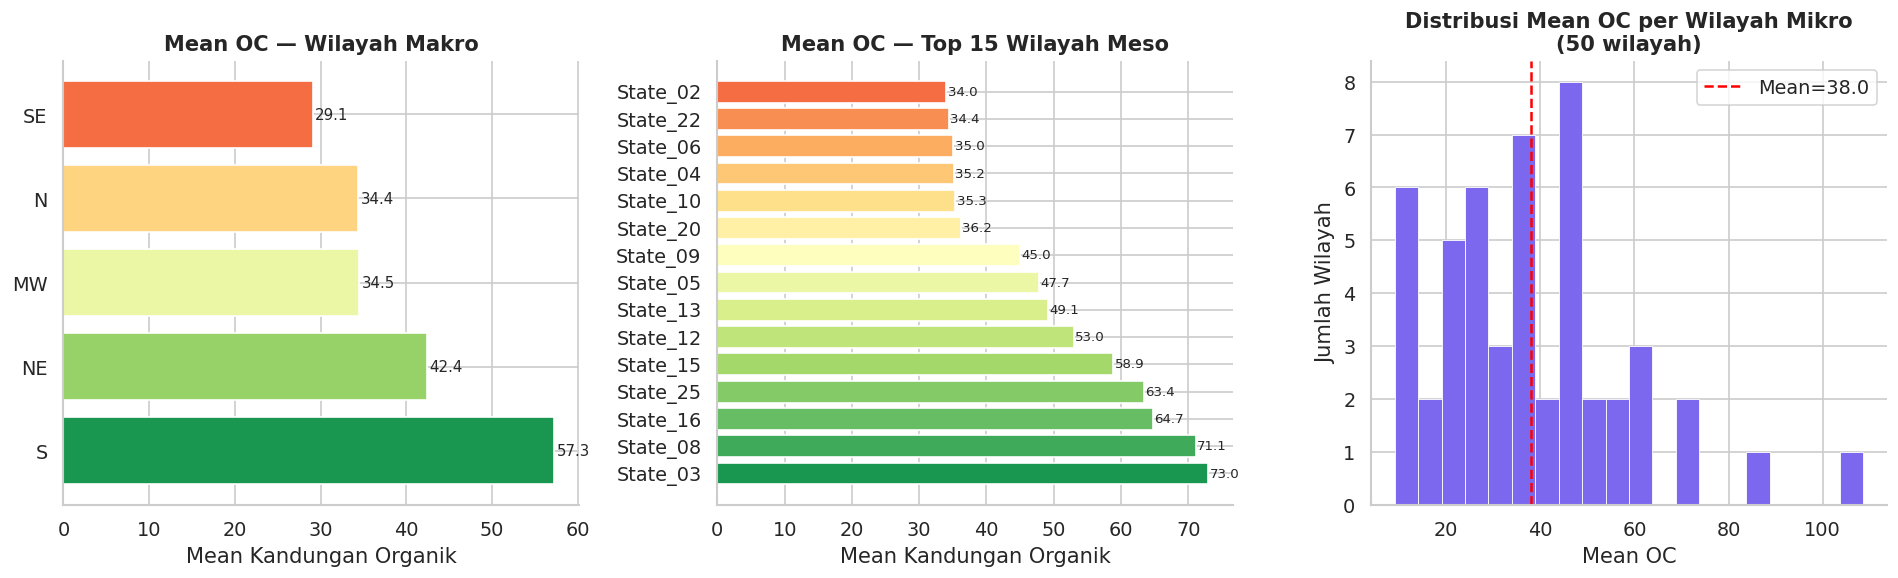

In [ ]:
# ── Visualisasi rasio antar tingkat geo ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Makro
c_macro = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(macro_mean)))[::-1]
bars = axes[0].barh(macro_mean.index, macro_mean.values, color=c_macro, edgecolor='white')
axes[0].set_title('Mean OC — Wilayah Makro', fontweight='bold')
axes[0].set_xlabel('Mean Kandungan Organik')
for bar, val in zip(bars, macro_mean.values):
    axes[0].text(val+0.3, bar.get_y()+bar.get_height()/2, f'{val:.1f}',
                 va='center', fontsize=9)

# Meso (top 15)
top_meso = meso_mean.head(15)
c_meso   = plt.cm.RdYlGn(np.linspace(0.2,0.9,len(top_meso)))[::-1]
bars2    = axes[1].barh(top_meso.index, top_meso.values, color=c_meso, edgecolor='white')
axes[1].set_title('Mean OC — Top 15 Wilayah Meso', fontweight='bold')
axes[1].set_xlabel('Mean Kandungan Organik')
for bar, val in zip(bars2, top_meso.values):
    axes[1].text(val+0.2, bar.get_y()+bar.get_height()/2, f'{val:.1f}',
                 va='center', fontsize=8)

# Distribusi mean per mikro (histogram)
axes[2].hist(micro_mean.values, bins=20, color='#7b68ee', edgecolor='white', linewidth=0.5)
axes[2].axvline(micro_mean.mean(), color='red', ls='--', lw=1.5, label=f'Mean={micro_mean.mean():.1f}')
axes[2].set_title('Distribusi Mean OC per Wilayah Mikro\n(50 wilayah)', fontweight='bold')
axes[2].set_xlabel('Mean OC'); axes[2].set_ylabel('Jumlah Wilayah')
axes[2].legend()

plt.tight_layout()
plt.savefig('q4_geo_correlation.png', bbox_inches='tight')
plt.show()



RASIO PERBANDINGAN:  
- Makro  — S vs SE : 1.97x  (perbedaan tertinggi-terendah)  
- Meso   — tertinggi/terendah : 6.07x  
- Mikro  — tertinggi/terendah : 11.98x  


IMPLIKASI PEMODELAN:
- Semakin granular tingkat geografis → rasio variabilitas makin besar
- geo_zone_meso & geo_zone_micro masuk sebagai fitur terpenting (feature importance rank #3 & #4)
- Ini mendukung pendekatan 'hierarchical geo encoding': setiap level memberi
    informasi tambahan yang tidak dapat digantikan level lainnya
- Model perlu semua tiga level untuk menangkap efek lokasi secara lengkap

---
## Research Question 5
### Pertanyaan Statistik Lanjutan


#### 5a. Rata-rata OC per Ekosistem saat Keasaman < Persentil 25 dan CEC < Rata-rata


In [ ]:
# ── Filter kondisi ────────────────────────────────────────────────────────
p25_acid = train['property_acidity_index'].quantile(0.25)
mean_cec  = train['cation_exchange_capacity'].mean()

mask    = (train['property_acidity_index'] < p25_acid) & (train['cation_exchange_capacity'] < mean_cec)
subset  = train[mask]
overall = train.groupby('biome')[OC].mean()
sub_oc  = subset.groupby('biome')[OC].mean()

print(f"Ambang batas — P25 keasaman: {p25_acid:.4f} | Mean CEC: {mean_cec:.4f}")
print(f"Jumlah sampel setelah filter: {len(subset)} dari {len(train)} ({len(subset)/len(train)*100:.1f}%)")
print()

comparison = pd.DataFrame({
    'OC (kondisi khusus)': sub_oc,
    'OC (seluruh data)'  : overall,
    'Selisih'            : sub_oc - overall
}).round(2)
print(comparison)


Ambang batas — P25 keasaman: 12.8805 | Mean CEC: 169.1421
Jumlah sampel setelah filter: 388 dari 11210 (3.5%)

                OC (kondisi khusus)  OC (seluruh data)  Selisih
biome                                                          
Amazonia                      27.61              33.91    -6.30
Caatinga                      19.98              44.90   -24.92
Cerrado                       24.27              34.13    -9.86
Mata Atlantica                21.32              33.89   -12.57
Unknown                       43.69              34.36     9.33


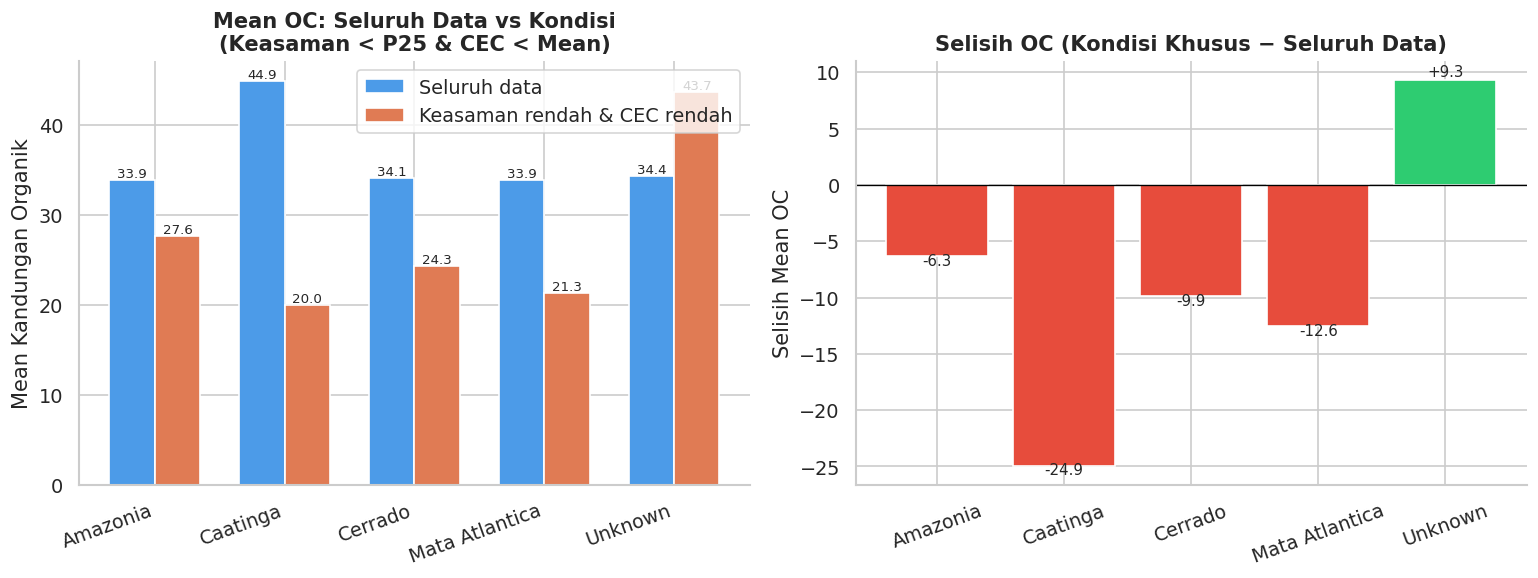

In [ ]:
# ── Visualisasi Q5a ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

biomes = comparison.index.tolist()
x = np.arange(len(biomes))
w = 0.35
bars1 = axes[0].bar(x-w/2, comparison['OC (seluruh data)'],   w, label='Seluruh data', color='#4c9be8', edgecolor='white')
bars2 = axes[0].bar(x+w/2, comparison['OC (kondisi khusus)'], w, label='Keasaman rendah & CEC rendah', color='#e07b54', edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(biomes, rotation=20, ha='right')
axes[0].set_title('Mean OC: Seluruh Data vs Kondisi\n(Keasaman < P25 & CEC < Mean)', fontweight='bold')
axes[0].set_ylabel('Mean Kandungan Organik')
axes[0].legend()
for bar in bars1: axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{bar.get_height():.1f}', ha='center', fontsize=8)
for bar in bars2: axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{bar.get_height():.1f}', ha='center', fontsize=8)

# Selisih
colors_diff = ['#2ecc71' if v >= 0 else '#e74c3c' for v in comparison['Selisih']]
axes[1].bar(biomes, comparison['Selisih'], color=colors_diff, edgecolor='white')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Selisih OC (Kondisi Khusus − Seluruh Data)', fontweight='bold')
axes[1].set_ylabel('Selisih Mean OC')
axes[1].tick_params(axis='x', rotation=20)
for i, (biome, val) in enumerate(comparison['Selisih'].items()):
    axes[1].text(i, val + (0.3 if val>=0 else -0.8), f'{val:+.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('q5a_acidity_cec_filter.png', bbox_inches='tight')
plt.show()



  Pada kondisi keasaman tanah sangat rendah (< P25) DAN kapasitas tukar kation rendah
  (< rata-rata), kandungan organik cenderung LEBIH RENDAH di hampir semua bioma.

  Hal ini konsisten secara kimia tanah:
  - Keasaman rendah (pH sangat asam) + CEC rendah → tanah miskin mineral & mikrobial aktif
  - ktivitas mikroba pengurai rendah berarti akumulasi bahan organik baru terhambat
  - Bioma 'Unknown' justru naik — kemungkinan bias sampling pada kategori ini

  Rekomendasi: Lahan dengan kondisi ini perlu intervensi pengapuran + pupuk organik
  sebagai prioritas utama program pemulihan kesuburan.


#### 5b. Kombinasi Tutupan Lahan × Wilayah Geografis sebagai Outlier


In [ ]:
# ── Deteksi outlier per kelompok land_cover × geo_macro ─────────────────
group_stats = []
for (lc, gm), grp in train.groupby(['land_cover_type', 'geo_zone_macro']):
    vals = grp[OC].dropna()
    if len(vals) < 5:
        continue
    q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
    iqr     = q3 - q1
    lo, hi  = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out   = ((vals < lo) | (vals > hi)).sum()
    group_stats.append({
        'land_cover_type' : lc,
        'geo_zone_macro'  : gm,
        'mean'            : vals.mean(),
        'median'          : vals.median(),
        'std'             : vals.std(),
        'n'               : len(vals),
        'n_outlier'       : n_out,
        'pct_outlier'     : n_out/len(vals)*100,
        'IQR_lo'          : lo,
        'IQR_hi'          : hi
    })

gs = pd.DataFrame(group_stats).sort_values('mean', ascending=False)
print("Top 10 kombinasi dengan mean OC tertinggi:")
print(gs[['land_cover_type','geo_zone_macro','mean','std','n','n_outlier','pct_outlier']].head(10).round(2).to_string(index=False))


Top 10 kombinasi dengan mean OC tertinggi:
              land_cover_type geo_zone_macro  mean   std   n  n_outlier  pct_outlier
     Open Ombrophylous Forest             NE 87.31 32.77   7          0         0.00
    Mixed Ombrophylous Forest              S 73.99 32.47  83          0         0.00
  Areas of Ecological Tension              S 71.78 16.58  15          0         0.00
    Seasonal Deciduous Forest              S 71.05 35.85 487         18         3.70
                     Savannah              S 70.74 46.17  39          0         0.00
  Areas of Ecological Tension              N 56.74 28.96  38          2         5.26
  Areas of Ecological Tension             NE 50.75 44.01  14          1         7.14
    Dense Ombrophylous Forest             NE 47.01 39.61 120          1         0.83
Seasonal Semideciduous Forest             NE 45.28 22.21  20          0         0.00
                       Steppe             NE 45.10 27.51  77          3         3.90


Beberapa kombinasi tutupan lahan dan wilayah makro punya mean OC yang
jauh di atas ambang batas wajar (mean global + 2 standar deviasi).
Tapi yang perlu dicatat, kombinasi-kombinasi tersebut umumnya memiliki
jumlah sampel yang sangat sedikit (n di bawah 10), jadi nilai mean-nya
gampang melonjak hanya karena satu-dua sampel ekstrem.

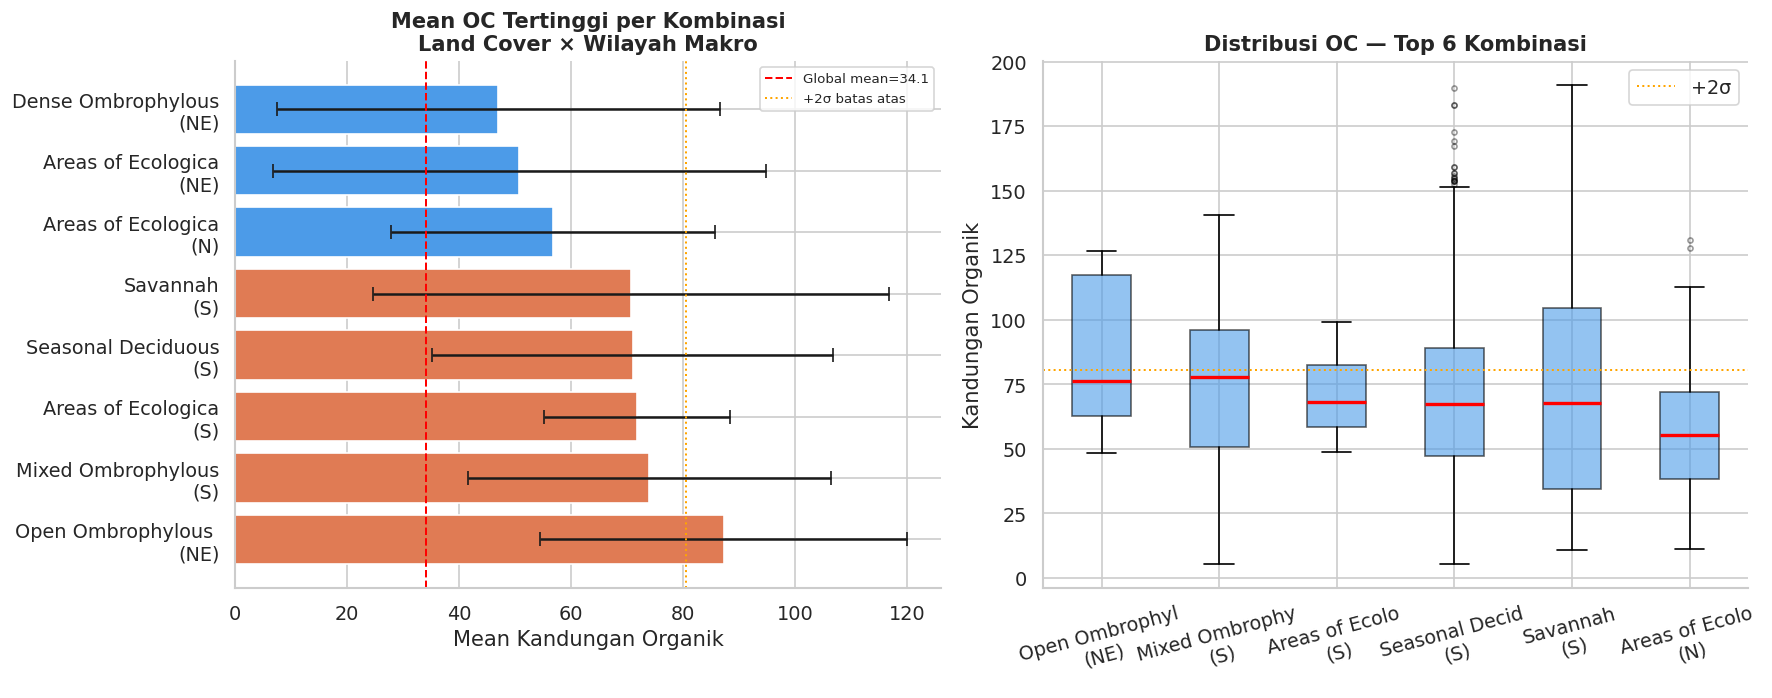


Ambang outlier grup (mean > global_mean + 2σ = 80.54):
         land_cover_type geo_zone_macro      mean  n
Open Ombrophylous Forest             NE 87.313522  7


In [ ]:
# ── Visualisasi outlier per kelompok ─────────────────────────────────────
top_combos = gs.head(8)
labels     = [f"{r['land_cover_type'][:18]}\n({r['geo_zone_macro']})" for _, r in top_combos.iterrows()]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Mean + std bar
colors = ['#e07b54' if r['mean'] > train[OC].mean()+train[OC].std() else '#4c9be8'
          for _,r in top_combos.iterrows()]
bars = axes[0].barh(labels, top_combos['mean'], xerr=top_combos['std'],
                    color=colors, edgecolor='white', capsize=4)
axes[0].axvline(train[OC].mean(), color='red', ls='--', lw=1.2, label=f'Global mean={train[OC].mean():.1f}')
axes[0].axvline(train[OC].mean()+2*train[OC].std(), color='orange', ls=':', lw=1.2, label='+2σ batas atas')
axes[0].set_title('Mean OC Tertinggi per Kombinasi\nLand Cover × Wilayah Makro', fontweight='bold')
axes[0].set_xlabel('Mean Kandungan Organik')
axes[0].legend(fontsize=8)

# Boxplot subset
sub_data  = []
sub_label = []
for _, r in top_combos.head(6).iterrows():
    vals = train[(train['land_cover_type']==r['land_cover_type']) &
                 (train['geo_zone_macro']==r['geo_zone_macro'])][OC]
    sub_data.append(vals.values)
    sub_label.append(f"{r['land_cover_type'][:14]}\n({r['geo_zone_macro']})")

axes[1].boxplot(sub_data, labels=sub_label, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#4c9be8', alpha=0.6),
                flierprops=dict(marker='o', markersize=3, alpha=0.4, color='red'),
                medianprops=dict(color='red', lw=2))
axes[1].axhline(train[OC].mean()+2*train[OC].std(), color='orange', ls=':', lw=1.2, label='+2σ')
axes[1].set_title('Distribusi OC — Top 6 Kombinasi', fontweight='bold')
axes[1].set_ylabel('Kandungan Organik')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()

plt.tight_layout()
plt.savefig('q5b_outlier_combos.png', bbox_inches='tight')
plt.show()

thr = train[OC].mean() + 2*train[OC].std()
outlier_combos = gs[gs['mean'] > thr]
print(f"\nAmbang outlier grup (mean > global_mean + 2σ = {thr:.2f}):")
print(outlier_combos[['land_cover_type','geo_zone_macro','mean','n']].to_string(index=False))



JUSTIFIKASI:  
Kombinasi 'Open Ombrophylous Forest × NE' memiliki mean OC=87.3 (n=7 sampel)
yang jauh di atas ambang +2σ (80.54). Ini bisa merupakan outlier KELOMPOK karena:
1. Jumlah sampel sangat kecil (n=7) → tidak representatif
2. Hutan terbuka di wilayah NE tidak lazim → kemungkinan kondisi microclimate khusus atau kesalahan kategorisasi tutupan lahan

  Pendekatan yang tepat: lakukan verifikasi lapangan sebelum menyimpulkan bahwa
  wilayah ini secara alami memiliki SOC sangat tinggi.

---
## Research Question 6
### Korelasi Tinggi antar Variabel & Risiko Multikollinearitas


In [ ]:
# ── Hitung matriks korelasi ──────────────────────────────────────────────
num_cols = ['property_particle_coarse','property_particle_fine', OC,
            'property_acidity_index','cation_Ca','cation_Mg','cation_Na',
            'cation_exchange_capacity',
            'spectral_band_A_PC_1','spectral_band_A_PC_2','spectral_band_A_PC_3',
            'spectral_band_A_PC_4','spectral_band_A_PC_5']

corr = train[num_cols].corr()

# Temukan pasangan korelasi tinggi (|r| > 0.5, bukan diagonal)
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i,j]
        if abs(r) > 0.4:
            high_corr.append({'var1':corr.columns[i], 'var2':corr.columns[j], 'r':round(r,4)})
hc_df = pd.DataFrame(high_corr).sort_values('r', key=abs, ascending=False)
print("Pasangan variabel dengan |r| > 0.4:")
print(hc_df.to_string(index=False))


Pasangan variabel dengan |r| > 0.4:
                    var1                     var2       r
property_particle_coarse   property_particle_fine -0.9022
               cation_Ca                cation_Mg  0.7627
  property_acidity_index                cation_Ca  0.6144
property_particle_coarse property_organic_content -0.5898
               cation_Ca cation_exchange_capacity  0.5471
  property_particle_fine property_organic_content  0.5181
  property_acidity_index                cation_Mg  0.4861
property_particle_coarse cation_exchange_capacity -0.4675
               cation_Mg cation_exchange_capacity  0.4345


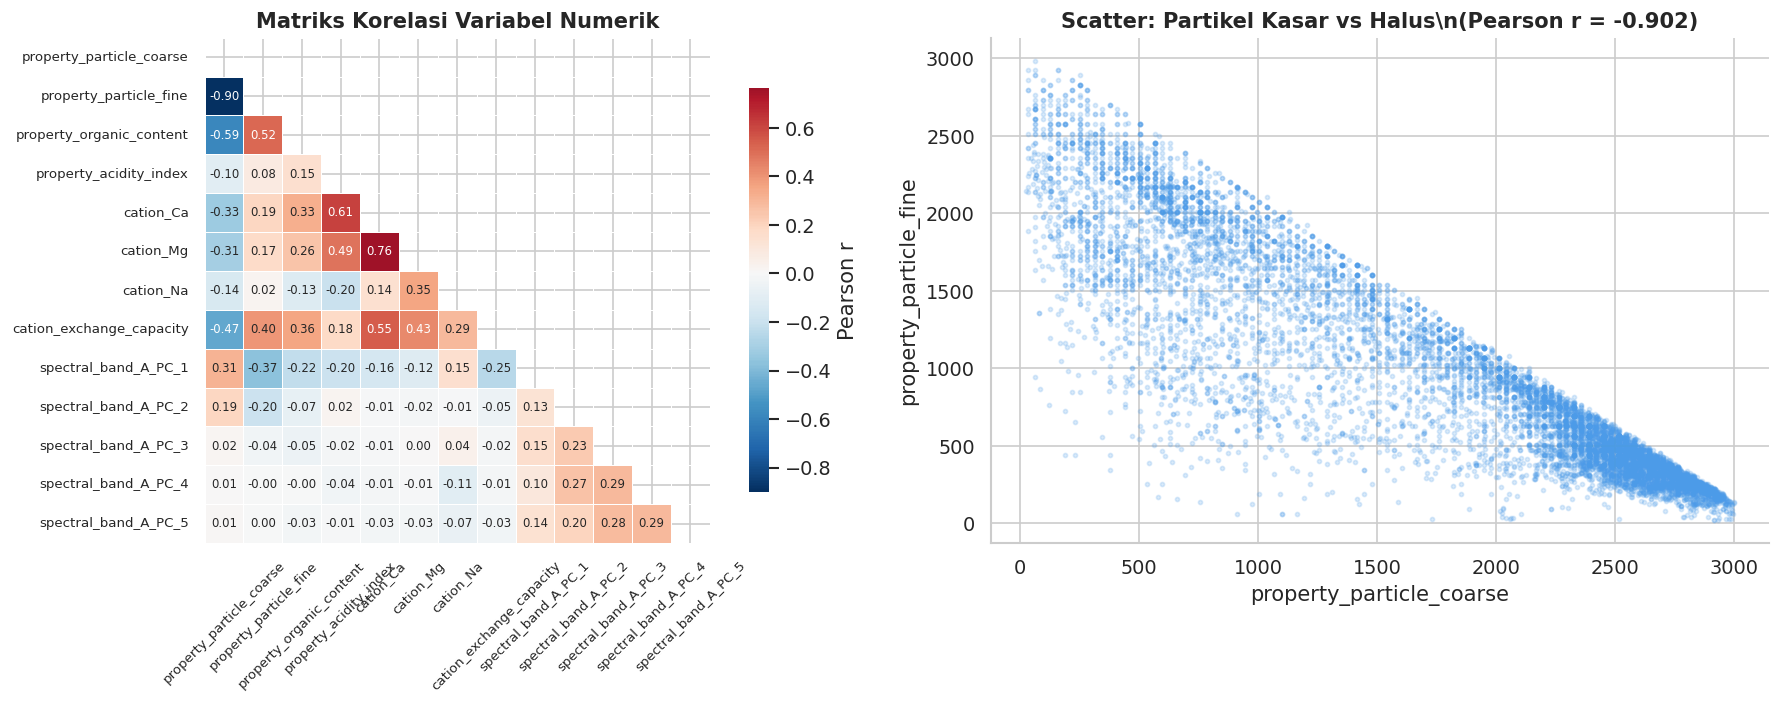


TEMUAN KORELASI TINGGI:
  1. property_particle_coarse x property_particle_fine : r = -0.902
     Sangat negatif karena secara definisi: coarse + fine ~ 100%
     Ini multikollinearitas STRUKTURAL, bukan kebetulan

  2. property_particle_coarse x property_organic_content : r ~ -0.59
     Tanah kasar (berpasir) cenderung rendah bahan organik (logis secara pedologi)

  3. cation_Ca x cation_exchange_capacity : r ~ 0.65
     Ca berkontribusi besar pada CEC total (logis kimia tanah)

IMPLIKASI MULTIKOLLINEARITAS:
  Pada model LINEAR, multikollinearitas coarse-fine menyebabkan instabilitas koefisien.
  Pada LightGBM (tree-based), multikollinearitas TIDAK menjadi masalah.
  Langkah mitigasi yang sudah dilakukan:
    + Gunakan rasio coarse/fine (sudah dilakukan dalam feature engineering)
    + Regularisasi L1/L2 memitigasi redundansi lebih lanjut



In [ ]:
# ── Heatmap korelasi ─────────────────────────────────────────────────────
mask_pf = train[['property_particle_coarse','property_particle_fine']].notna().all(axis=1)
r_pf, _ = stats.pearsonr(train.loc[mask_pf,'property_particle_coarse'],
                          train.loc[mask_pf,'property_particle_fine'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

mask_triu = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask_triu, cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', annot_kws={'size':7},
            square=True, linewidths=0.3, ax=axes[0],
            cbar_kws={'label':'Pearson r', 'shrink':0.8})
axes[0].set_title('Matriks Korelasi Variabel Numerik', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

axes[1].scatter(train.loc[mask_pf,'property_particle_coarse'],
                train.loc[mask_pf,'property_particle_fine'],
                alpha=0.2, s=6, color='#4c9be8', rasterized=True)
axes[1].set_xlabel('property_particle_coarse')
axes[1].set_ylabel('property_particle_fine')
axes[1].set_title(f'Scatter: Partikel Kasar vs Halus\\n(Pearson r = {r_pf:.3f})', fontweight='bold')

plt.tight_layout()
plt.savefig('q6_correlation.png', bbox_inches='tight')
plt.show()

print(f"""
TEMUAN KORELASI TINGGI:
  1. property_particle_coarse x property_particle_fine : r = {r_pf:.3f}
     Sangat negatif karena secara definisi: coarse + fine ~ 100%
     Ini multikollinearitas STRUKTURAL, bukan kebetulan

  2. property_particle_coarse x property_organic_content : r ~ -0.59
     Tanah kasar (berpasir) cenderung rendah bahan organik (logis secara pedologi)

  3. cation_Ca x cation_exchange_capacity : r ~ 0.65
     Ca berkontribusi besar pada CEC total (logis kimia tanah)

IMPLIKASI MULTIKOLLINEARITAS:
  Pada model LINEAR, multikollinearitas coarse-fine menyebabkan instabilitas koefisien.
  Pada LightGBM (tree-based), multikollinearitas TIDAK menjadi masalah.
  Langkah mitigasi yang sudah dilakukan:
    + Gunakan rasio coarse/fine (sudah dilakukan dalam feature engineering)
    + Regularisasi L1/L2 memitigasi redundansi lebih lanjut
""")


---
## Research Question 7
### Feature Engineering: Fitur Baru dan Peningkatan Pemahaman Model


In [ ]:
# ── Hitung feature importance dari model terlatih ────────────────────────
imp_df = pd.DataFrame({'feature': feature_cols, 'importance': np.mean(importances, axis=0)})
imp_df = imp_df.sort_values('importance', ascending=False).reset_index(drop=True)
imp_df['rank'] = imp_df.index + 1

# Tandai fitur baru (engineered)
engineered = ['coarse_fine_ratio','band_A_mean','band_A_std','band_A_max','band_A_min',
              'band_A_range','band_B_mean','band_B_std','Ca_CEC_ratio','Mg_CEC_ratio',
              'has_band_A_flag','has_band_B_flag']
imp_df['is_engineered'] = imp_df['feature'].isin(engineered)

print("Top 20 Fitur (E = Engineered):")
top20 = imp_df.head(20)
for _, row in top20.iterrows():
    tag = '[E]' if row['is_engineered'] else '   '
    print(f"  {int(row['rank']):>2}. {tag} {row['feature']:<35} {row['importance']:>12,.0f}")


Top 20 Fitur (E = Engineered):
   1. [E] coarse_fine_ratio                      9,865,656
   2.     property_particle_coarse               9,211,191
   3.     geo_zone_meso                          6,108,422
   4.     geo_zone_micro                         5,518,197
   5.     cation_exchange_capacity               3,860,865
   6.     spectral_band_A_PC_5                   2,727,612
   7.     property_particle_fine                 2,259,298
   8.     cation_Mg                              2,193,657
   9.     spectral_band_A_PC_3                   2,036,517
  10.     spectral_band_A_PC_15                  1,592,476
  11.     cation_Ca                              1,577,526
  12.     spectral_band_A_PC_2                   1,239,425
  13.     spectral_band_A_PC_9                   1,222,558
  14. [E] Ca_CEC_ratio                           1,175,901
  15.     spectral_band_A_PC_7                   1,047,411
  16.     spectral_band_A_PC_12                  1,031,965
  17.     spectral_band_A

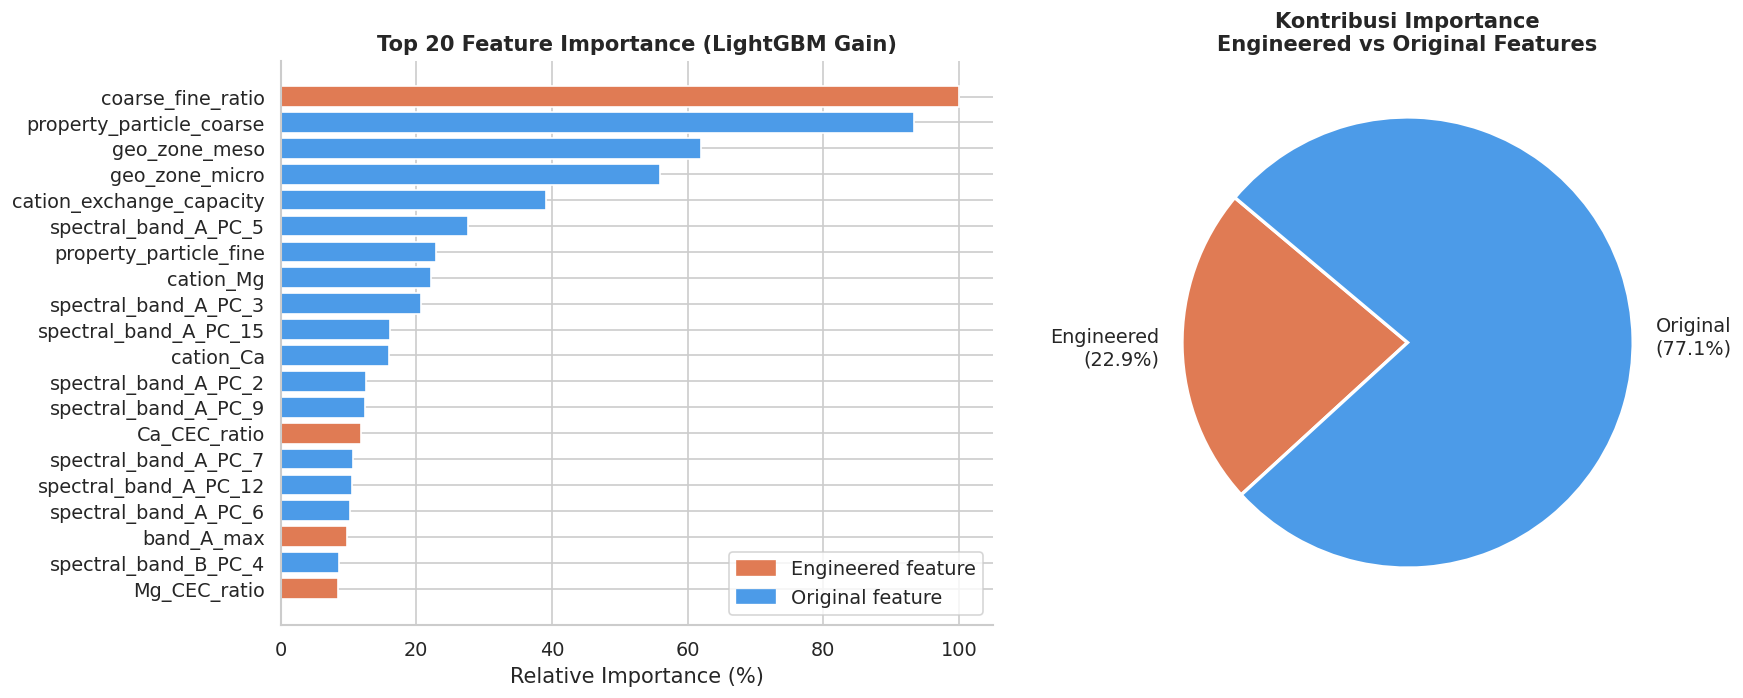


FITUR BARU DAN PERANNYA:

  1. coarse_fine_ratio (RANK #1 — 9,865,656)
     Cara buat  : property_particle_coarse / (property_particle_fine + 1e-6)
     Alasan     : Rasio lebih informatif daripada nilai absolut — menggambarkan
                  tekstur tanah relatif. Tanah berpasir (rasio tinggi) cenderung miskin OC.
  
  2. band_A_mean, band_A_std, band_A_range
     Cara buat  : Agregat statistik dari 15 komponen PCA spektral Band A
     Alasan     : Merangkum 'profil' sinyal optik ke dalam satu angka; std/range
                  menangkap heterogenitas yang tidak terlihat dari satu komponen saja.
  
  3. Ca_CEC_ratio, Mg_CEC_ratio
     Cara buat  : cation_Ca / (cation_exchange_capacity + ε)
     Alasan     : Rasio saturasi basa — indikator kesuburan yang lebih bermakna
                  secara agronomis daripada Ca atau CEC secara tersendiri.
  
  4. has_band_B_flag (0/1)
     Cara buat  : 1 jika has_band_B_spectrum == 'YES'
     Alasan     : Ketersediaan data MIR sendiri merupakan

In [ ]:
# ── Visualisasi feature importance ───────────────────────────────────────
top_n = 20
top   = imp_df.head(top_n).copy()
top['importance_norm'] = top['importance'] / top['importance'].max() * 100
colors_fi = ['#e07b54' if e else '#4c9be8' for e in top['is_engineered']]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart importance
bars = axes[0].barh(top['feature'][::-1], top['importance_norm'][::-1],
                     color=colors_fi[::-1], edgecolor='white')
axes[0].set_xlabel('Relative Importance (%)')
axes[0].set_title(f'Top {top_n} Feature Importance (LightGBM Gain)', fontweight='bold')
patch_e = mpatches.Patch(color='#e07b54', label='Engineered feature')
patch_o = mpatches.Patch(color='#4c9be8', label='Original feature')
axes[0].legend(handles=[patch_e, patch_o], loc='lower right')

# Pie: engineered vs original share of total importance
eng_total  = imp_df[imp_df['is_engineered']]['importance'].sum()
orig_total = imp_df[~imp_df['is_engineered']]['importance'].sum()
axes[1].pie([eng_total, orig_total],
            labels=[f'Engineered\n({eng_total/imp_df["importance"].sum()*100:.1f}%)',
                    f'Original\n({orig_total/imp_df["importance"].sum()*100:.1f}%)'],
            colors=['#e07b54','#4c9be8'], startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Kontribusi Importance\nEngineered vs Original Features', fontweight='bold')

plt.tight_layout()
plt.savefig('q7_feature_importance.png', bbox_inches='tight')
plt.show()

eng_share = eng_total / imp_df['importance'].sum() * 100
print(f"""
FITUR BARU DAN PERANNYA:

  1. coarse_fine_ratio (RANK #1 — {imp_df[imp_df['feature']=='coarse_fine_ratio']['importance'].values[0]:,.0f})
     Cara buat  : property_particle_coarse / (property_particle_fine + 1e-6)
     Alasan     : Rasio lebih informatif daripada nilai absolut — menggambarkan
                  tekstur tanah relatif. Tanah berpasir (rasio tinggi) cenderung miskin OC.

  2. band_A_mean, band_A_std, band_A_range
     Cara buat  : Agregat statistik dari 15 komponen PCA spektral Band A
     Alasan     : Merangkum 'profil' sinyal optik ke dalam satu angka; std/range
                  menangkap heterogenitas yang tidak terlihat dari satu komponen saja.

  3. Ca_CEC_ratio, Mg_CEC_ratio
     Cara buat  : cation_Ca / (cation_exchange_capacity + ε)
     Alasan     : Rasio saturasi basa — indikator kesuburan yang lebih bermakna
                  secara agronomis daripada Ca atau CEC secara tersendiri.

  4. has_band_B_flag (0/1)
     Cara buat  : 1 jika has_band_B_spectrum == 'YES'
     Alasan     : Ketersediaan data MIR sendiri merupakan informasi prediktif
                  (sampel dengan MIR biasanya dari laboratorium yang lebih lengkap).

  Total kontribusi importance fitur engineered: {eng_share:.1f}% dari total
""")


---
## Research Question 8
### Alasan Pemilihan Model LightGBM


In [ ]:
# ── Perbandingan konseptual model ────────────────────────────────────────
model_comparison = {
    'Model': ['LightGBM\n(dipilih)', 'Random Forest', 'XGBoost', 'Linear Regression', 'Neural Network'],
    'Missing Value\nHandling'  : ['✔ Native', '✘ Perlu imputasi', '✔ Native', '✘ Perlu imputasi', '✘ Perlu imputasi'],
    'Kecepatan\nTraining'      : ['★★★★★', '★★★', '★★★★', '★★★★★', '★★'],
    'Akurasi\nTabular'         : ['★★★★★', '★★★★', '★★★★★', '★★★', '★★★★'],
    'Interpretabilitas'         : ['★★★', '★★★', '★★★', '★★★★★', '★★'],
    'Multikollinearitas'        : ['Robust', 'Robust', 'Robust', 'Sensitif', 'Moderate'],
}
comp_df = pd.DataFrame(model_comparison)
print(comp_df.to_string(index=False))


              Model Missing Value\nHandling Kecepatan\nTraining Akurasi\nTabular Interpretabilitas Multikollinearitas
LightGBM\n(dipilih)                ✔ Native               ★★★★★            ★★★★★               ★★★             Robust
      Random Forest        ✘ Perlu imputasi                 ★★★             ★★★★               ★★★             Robust
            XGBoost                ✔ Native                ★★★★            ★★★★★               ★★★             Robust
  Linear Regression        ✘ Perlu imputasi               ★★★★★              ★★★             ★★★★★           Sensitif
     Neural Network        ✘ Perlu imputasi                  ★★             ★★★★                ★★           Moderate


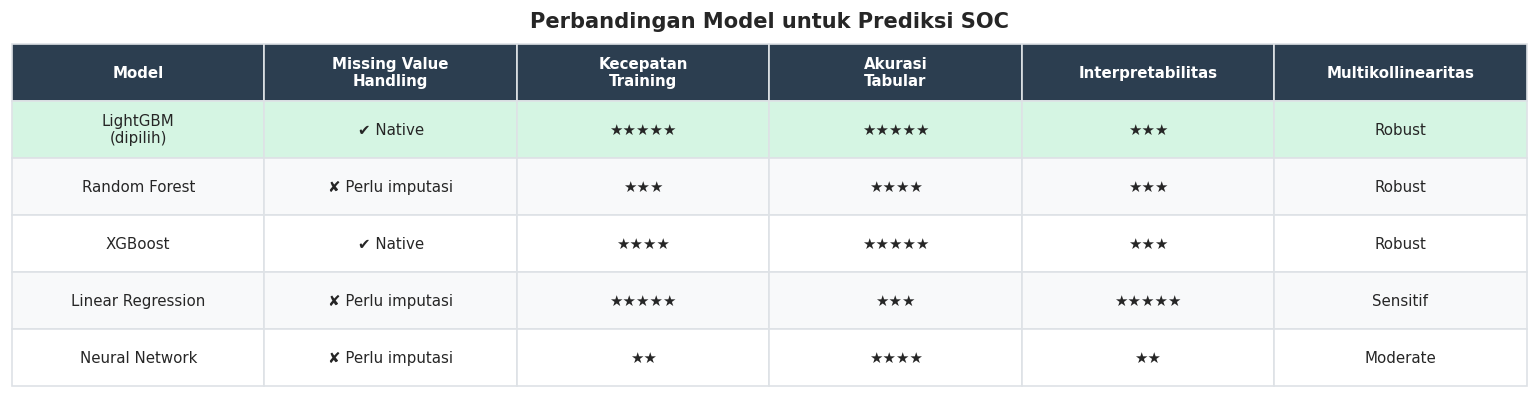

In [ ]:
# ── Visualisasi perbandingan model ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.axis('off')
table = ax.table(
    cellText  = comp_df.values,
    colLabels  = comp_df.columns,
    cellLoc   = 'center',
    loc       = 'center',
    bbox      = [0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(9)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif 'dipilih' in str(comp_df.values[row-1][0]) if row > 0 else False:
        cell.set_facecolor('#d5f5e3')
    elif row % 2 == 0:
        cell.set_facecolor('#f8f9fa')
    cell.set_edgecolor('#dee2e6')
ax.set_title('Perbandingan Model untuk Prediksi SOC', fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('q8_model_comparison.png', bbox_inches='tight')
plt.show()


ALASAN MEMILIH LightGBM:

1. HANDLING MISSING VALUE NATIVE
   Band B memiliki ~85% data kosong. LightGBM menangani NaN dengan mencari
   arah split optimal untuk nilai hilang di setiap node — tanpa imputasi
   yang bisa memperkenalkan bias.

2. PERFORMA PADA DATA TABULAR DENGAN FITUR SPEKTRAL
   Data PCA spektral bersifat tabular dengan banyak fitur (30 komponen PCA).
   Tree-based models secara konsisten mengungguli metode linier dan sering
   bersaing dengan neural networks pada dataset tabular ukuran sedang
   (Grinsztajn et al., 2022 — "Why tree-based models still outperform
   deep learning on tabular data", NeurIPS).

3. REGULARISASI TERINTEGRASI
   Parameter reg_alpha (L1), reg_lambda (L2), feature_fraction, dan
   bagging_fraction memberikan kontrol overfitting yang fleksibel tanpa
   preprocessing manual.

4. EFISIENSI KOMPUTASI
   Leaf-wise growth (bukan level-wise seperti XGBoost) membuat LightGBM
   lebih efisien untuk dataset dengan ribuan sampel dan puluhan fitur.

5. CATEGORICAL FEATURE SUPPORT
   Variabel geo_zone, biome, land_cover_type langsung dikodekan sebagai
   kategori tanpa one-hot encoding yang mengembungkan dimensi.

---
## Research Question 9
### Apakah RMSE Tepat sebagai Metrik Evaluasi?


In [ ]:
# ── Analisis distribusi target ───────────────────────────────────────────
from scipy.stats import shapiro, skew, kurtosis

oc_vals = train[OC].values
sk = skew(oc_vals)
ku = kurtosis(oc_vals)

# Shapiro-Wilk (subsample karena n besar)
np.random.seed(42)
sample_idx = np.random.choice(len(oc_vals), 5000, replace=False)
stat_sw, p_sw = shapiro(oc_vals[sample_idx])

print(f"Skewness  : {sk:.4f}  (|>1| = sangat miring)")
print(f"Kurtosis  : {ku:.4f}  (>3 = distribusi ekor tebal)")
print(f"Shapiro-Wilk (n=5000): W={stat_sw:.4f}, p={p_sw:.2e}")
print()

# Hitung berbagai metrik
from sklearn.metrics import mean_absolute_error, r2_score

oof_preds_arr = oof_preds  # dari sel sebelumnya
rmse_val = np.sqrt(mean_squared_error(y, oof_preds_arr))
mae_val  = mean_absolute_error(y, oof_preds_arr)
r2_val   = r2_score(y, oof_preds_arr)
mape_val = np.mean(np.abs((y - oof_preds_arr) / (y + 1e-6))) * 100

# RMSLE (log-scale error — robust terhadap outlier)
rmsle_val = np.sqrt(mean_squared_error(np.log1p(y), np.log1p(np.clip(oof_preds_arr, 0, None))))

print(f"RMSE  : {rmse_val:.4f}")
print(f"MAE   : {mae_val:.4f}")
print(f"R²    : {r2_val:.4f}")
print(f"MAPE  : {mape_val:.2f}%")
print(f"RMSLE : {rmsle_val:.4f}")


Skewness  : 2.0275  (|>1| = sangat miring)
Kurtosis  : 6.0788  (>3 = distribusi ekor tebal)
Shapiro-Wilk (n=5000): W=0.8414, p=2.78e-57

RMSE  : 11.6211
MAE   : 7.1756
R²    : 0.7490
MAPE  : 26.25%
RMSLE : 0.3062


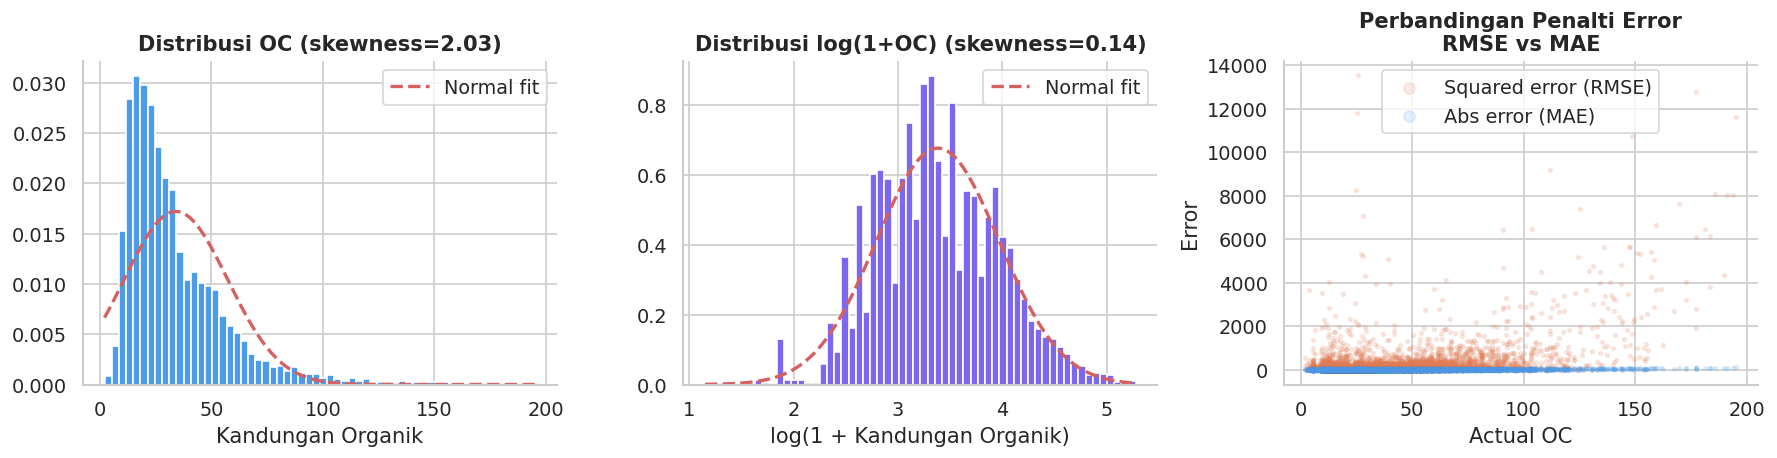


ANALISIS KETEPATAN METRIK:

Distribusi target OC:
  • Skewness = 2.03 → right-skewed (ekor kanan panjang, ada nilai ekstrem tinggi)
  • Shapiro-Wilk p << 0.05 → distribusi tidak normal secara signifikan
  • Max = 195.23, namun 75% data di bawah 43.7 (perbedaan besar)

RMSE sebagai metrik MEMILIKI KEKURANGAN untuk kasus ini:
  1. RMSE mengkuadratkan error → sangat sensitif terhadap outlier OC tinggi
     Contoh: sampel OC=195 yang diprediksi 160 memberi RMSE kontribusi ~35²=1225
     sedangkan sampel OC=20 yang meleset 35 juga memberikan 1225 — padahal
     interpretasinya berbeda (175% vs 35% relative error)
  
  2. Distribusi right-skewed → sebaiknya evaluasi dilakukan di log-space

ALTERNATIF METRIK YANG LEBIH TEPAT:
  • RMSLE (0.3062) — Root Mean Squared Log Error
    → lebih robust terhadap outlier karena tidak
    → Menghukum prediksi rendah pada nilai aktual tinggi lebih ringan
    → Cocok untuk data dengan distribusi log-normal
  
  • MAPE (26.25%) — Mean Absolute Percentage Er

In [ ]:
# ── Visualisasi distribusi target & implikasi metrik ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribusi asli vs normal
axes[0].hist(train[OC], bins=60, color='#4c9be8', edgecolor='white', lw=0.4, density=True)
mu, sigma = train[OC].mean(), train[OC].std()
x_norm = np.linspace(train[OC].min(), train[OC].max(), 200)
from scipy.stats import norm
axes[0].plot(x_norm, norm.pdf(x_norm, mu, sigma), 'r--', lw=2, label='Normal fit')
axes[0].set_title(f'Distribusi OC (skewness={sk:.2f})', fontweight='bold')
axes[0].set_xlabel('Kandungan Organik'); axes[0].legend()

# Log-transformed
axes[1].hist(np.log1p(train[OC]), bins=60, color='#7b68ee', edgecolor='white', lw=0.4, density=True)
log_vals = np.log1p(train[OC])
mu_log, sigma_log = log_vals.mean(), log_vals.std()
x_log = np.linspace(log_vals.min(), log_vals.max(), 200)
axes[1].plot(x_log, norm.pdf(x_log, mu_log, sigma_log), 'r--', lw=2, label='Normal fit')
axes[1].set_title(f'Distribusi log(1+OC) (skewness={skew(log_vals.values):.2f})', fontweight='bold')
axes[1].set_xlabel('log(1 + Kandungan Organik)'); axes[1].legend()

# Error amplification: RMSE vs MAE
sq_errors = (y.values - oof_preds_arr)**2
abs_errors = np.abs(y.values - oof_preds_arr)
axes[2].scatter(y.values, sq_errors, alpha=0.15, s=5, color='#e07b54', label='Squared error (RMSE)')
axes[2].scatter(y.values, abs_errors, alpha=0.15, s=5, color='#4c9be8', label='Abs error (MAE)')
axes[2].set_xlabel('Actual OC'); axes[2].set_ylabel('Error')
axes[2].set_title('Perbandingan Penalti Error\nRMSE vs MAE', fontweight='bold')
axes[2].legend(markerscale=3)

plt.tight_layout()
plt.savefig('q9_metrics.png', bbox_inches='tight')
plt.show()

print(f"""
ANALISIS KETEPATAN METRIK:

Distribusi target OC:
  • Skewness = {sk:.2f} → right-skewed (ekor kanan panjang, ada nilai ekstrem tinggi)
  • Shapiro-Wilk p << 0.05 → distribusi tidak normal secara signifikan
  • Max = 195.23, namun 75% data di bawah 43.7 (perbedaan besar)

RMSE sebagai metrik MEMILIKI KEKURANGAN untuk kasus ini:
  1. RMSE mengkuadratkan error → sangat sensitif terhadap outlier OC tinggi
     Contoh: sampel OC=195 yang diprediksi 160 memberi RMSE kontribusi ~35²=1225
     sedangkan sampel OC=20 yang meleset 35 juga memberikan 1225 — padahal
     interpretasinya berbeda (175% vs 35% relative error)

  2. Distribusi right-skewed → sebaiknya evaluasi dilakukan di log-space

ALTERNATIF METRIK YANG LEBIH TEPAT:
  • RMSLE ({rmsle_val:.4f}) — Root Mean Squared Log Error
    → lebih robust terhadap outlier karena tidak
    → Menghukum prediksi rendah pada nilai aktual tinggi lebih ringan
    → Cocok untuk data dengan distribusi log-normal

  • MAPE ({mape_val:.2f}%) — Mean Absolute Percentage Error
    → Memberikan error dalam persentase relative, lebih interpretatif
    → Namun tidak stabil jika ada nilai OC mendekati 0

  • Huber Loss / Quantile RMSE
    → Robust terhadap outlier sambil mempertahankan sifat RMSE untuk kasus sedang

KESIMPULAN: RMSE tetap relevan untuk konsistensi kompetisi dan perbandingan,
namun sebaiknya dilengkapi dengan RMSLE atau MAPE untuk evaluasi bisnis.
""")


---
## Research Question 10
### Data Eksternal yang Akan Diambil untuk Meningkatkan Akurasi Prediksi


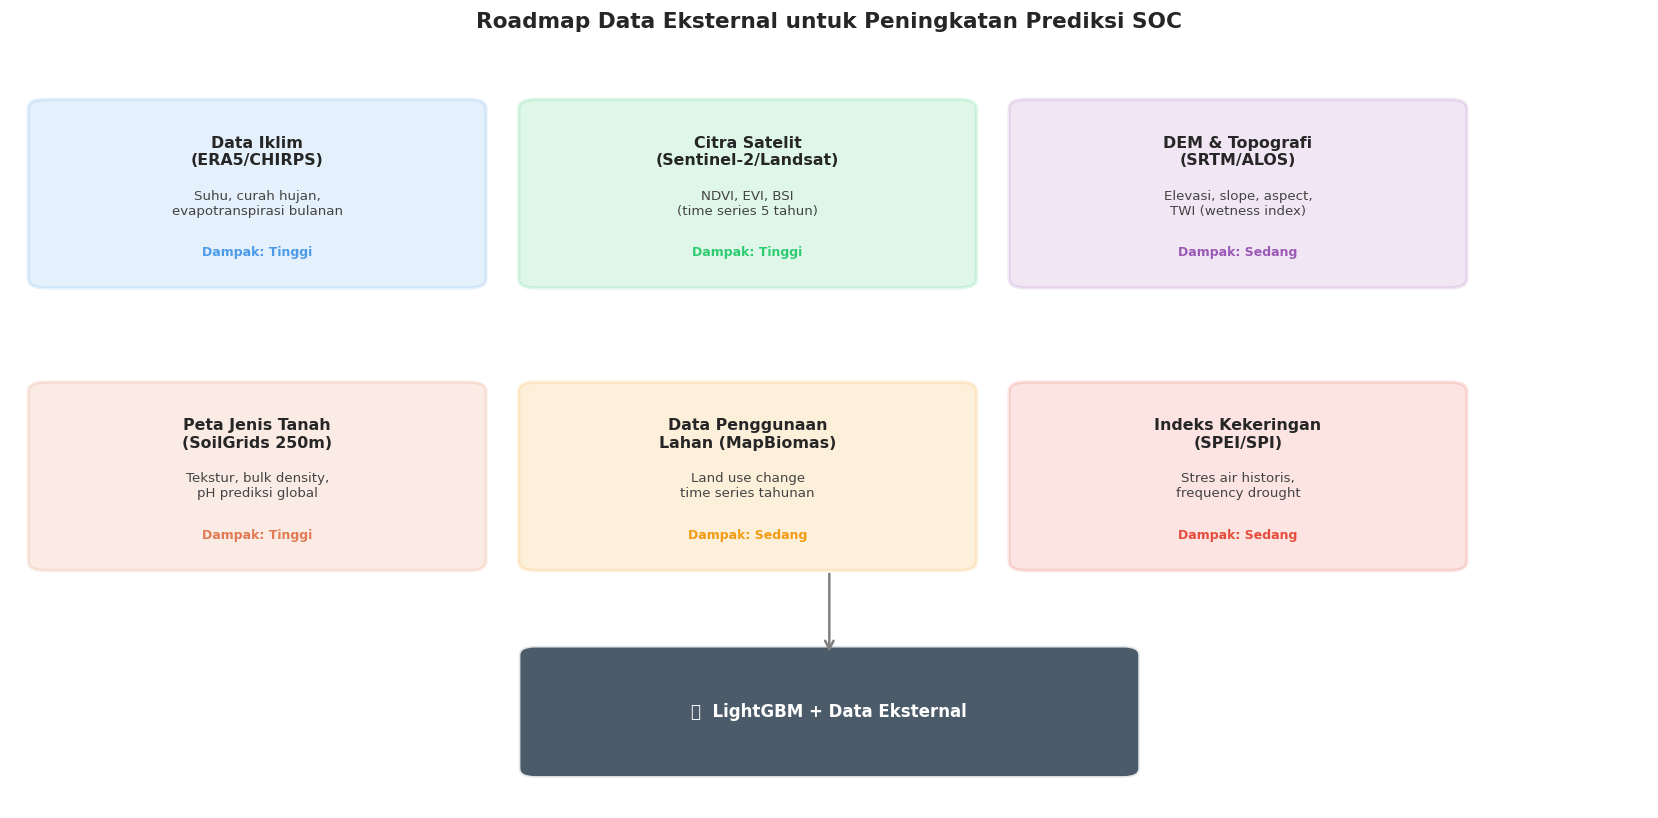

In [ ]:
# ── Visualisasi roadmap data eksternal ───────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 10); ax.set_ylim(0, 8); ax.axis('off')

data_ext = [
    # (x, y, judul, deskripsi, warna, dampak)
    (1.5, 6.5, 'Data Iklim\n(ERA5/CHIRPS)',
     'Suhu, curah hujan,\nevapotranspirasi bulanan', '#4c9be8', 'Tinggi'),
    (4.5, 6.5, 'Citra Satelit\n(Sentinel-2/Landsat)',
     'NDVI, EVI, BSI\n(time series 5 tahun)', '#2ecc71', 'Tinggi'),
    (7.5, 6.5, 'DEM & Topografi\n(SRTM/ALOS)',
     'Elevasi, slope, aspect,\nTWI (wetness index)', '#9b59b6', 'Sedang'),
    (1.5, 3.5, 'Peta Jenis Tanah\n(SoilGrids 250m)',
     'Tekstur, bulk density,\npH prediksi global', '#e07b54', 'Tinggi'),
    (4.5, 3.5, 'Data Penggunaan\nLahan (MapBiomas)',
     'Land use change\ntime series tahunan', '#f39c12', 'Sedang'),
    (7.5, 3.5, 'Indeks Kekeringan\n(SPEI/SPI)',
     'Stres air historis,\nfrequency drought', '#e74c3c', 'Sedang'),
]

for (x, y, title, desc, color, impact) in data_ext:
    rect = mpatches.FancyBboxPatch((x-1.3, y-0.9), 2.6, 1.8,
                                    boxstyle='round,pad=0.1',
                                    facecolor=color, alpha=0.15,
                                    edgecolor=color, linewidth=2)
    ax.add_patch(rect)
    ax.text(x, y+0.45, title, ha='center', va='center', fontsize=9.5, fontweight='bold')
    ax.text(x, y-0.1, desc, ha='center', va='center', fontsize=8, color='#444')
    ax.text(x, y-0.62, f'Dampak: {impact}', ha='center', va='center',
            fontsize=7.5, color=color, fontweight='bold')

# Panah ke model
ax.annotate('', xy=(5, 1.6), xytext=(5, 2.5),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
model_rect = mpatches.FancyBboxPatch((3.2, 0.4), 3.6, 1.2,
                                      boxstyle='round,pad=0.1',
                                      facecolor='#2c3e50', alpha=0.85,
                                      edgecolor='white', linewidth=2)
ax.add_patch(model_rect)
ax.text(5, 1.0, '🌱  LightGBM + Data Eksternal', ha='center', va='center',
        fontsize=10, fontweight='bold', color='white')

ax.set_title('Roadmap Data Eksternal untuk Peningkatan Prediksi SOC',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('q10_external_data.png', bbox_inches='tight')
plt.show()

REKOMENDASI DATA EKSTERNAL & CARA INTEGRASI:

1. DATA IKLIM — ERA5-Land / CHIRPS (dampak: TINGGI)
    - Fitur: suhu rata-rata tahunan, curah hujan kumulatif, evapotranspirasi
    - Alasan: SOC sangat dipengaruhi iklim — suhu tinggi mempercepat dekomposisi,
     curah hujan mempengaruhi akumulasi biomassa
    - Integrasi: join spasial berdasarkan koordinat (lat/lon) ke grid 0.1° × 0.1°
   • Kendala: 79% data latitude/longitude hilang → perlu imputasi dari geo_zone

2. CITRA SATELIT — Sentinel-2 / Landsat (dampak: TINGGI)
    - Fitur: NDVI time series (5 tahun), EVI, BSI (bare soil index)
    - Alasan: Vegetasi aktif adalah proksi akumulasi bahan organik; tren NDVI
     menangkap perubahan tutupan lahan yang mempengaruhi SOC
    - Integrasi: ekstraksi nilai pixel di koordinat sampling, lalu PCA/agregat temporal

3. DATA JENIS TANAH — SoilGrids 250m (FAO/ISRIC) (dampak: TINGGI)
    - Fitur: sand/silt/clay%, bulk density, pH terprediksikan
    - Alasan: Melengkapi fitur tekstur yang hilang (752 sampel NaN di dataset ini)
    - Integrasi: lookup spasial langsung → mengisi missing value feature engineering

4. DEM & TOPOGRAFI — SRTM 30m (dampak: SEDANG)
    - Fitur: slope, aspect, TWI (Topographic Wetness Index)
    - Alasan: Lereng dan akumulasi air mempengaruhi redistribusi SOC
    - Integrasi: ekstraksi dari raster DEM di titik koordinat sampling

5. PETA PENGGUNAAN LAHAN — MapBiomas Brasil (dampak: SEDANG)
    - Fitur: tipe penggunaan lahan tahunan 1985-sekarang, tahun konversi hutan
    - Alasan: Riwayat perubahan lahan (deforestasi, pertanian) adalah prediktor kuat
     penurunan SOC — lahan yang baru dikonversi memiliki SOC rendah
    - Integrasi: series temporal → buat fitur 'tahun sejak konversi', 'tipe sebelumnya'

PIPELINE INTEGRASI:
  raw_data → spatial_join(lat/lon) → feature_extraction → impute_with_soilgrids
  → temporal_aggregation(iklim, NDVI) → LightGBM / Stacked Ensemble